In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


SEED = 42
OUT  = '../output/'
RAW  = r'C:\Users\DorothyCheruiyot\Desktop\Projects\insurance_claims\data\insurance_data_features.xlsx'


## Helper Functions — Metrics

In [2]:
def tweedie_deviance(y_true, y_pred, p=1.5):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.clip(np.array(y_pred, dtype=float), 1e-10, None)
    if p == 1:
        return float(2 * np.sum(y_true * np.log(np.where(y_true > 0,
                     y_true / y_pred, 1)) - (y_true - y_pred)))
    t1 = np.where(y_true > 0, y_true**(2-p) / ((1-p)*(2-p)), 0.0)
    t2 = y_true * y_pred**(1-p) / (1-p)
    t3 = y_pred**(2-p) / (2-p)
    return float(2 * np.sum(t1 - t2 + t3))

def calibration_pct(y_true, y_pred):
    return float((np.sum(y_pred) - np.sum(y_true)) / np.sum(y_true) * 100)

def gini_coefficient(y_true, y_pred):
    idx = np.argsort(y_pred)
    ys  = np.array(y_true, dtype=float)[idx]
    cs  = np.cumsum(ys)
    if cs[-1] == 0: return 0.0
    return float((len(ys) + 1 - 2 * np.sum(cs) / cs[-1]) / len(ys))

def lift_table(y_true, y_pred, n=10):
    df_l = pd.DataFrame({'y': np.array(y_true, float), 'p': np.array(y_pred, float)})
    df_l['d'] = pd.qcut(df_l['p'], n, labels=False, duplicates='drop')
    return df_l.groupby('d').agg(actual=('y','mean'), predicted=('p','mean'),
                                  count=('y','count')).reset_index()

def score(name, y_true, y_pred, p=1.5):
    y_t = np.array(y_true, dtype=float)
    y_p = np.array(y_pred, dtype=float)
    return {
        'model': name,
        'tweedie_deviance': round(tweedie_deviance(y_t, y_p, p), 4),
        'calibration_%'   : round(calibration_pct(y_t, y_p), 3),
        'gini' : round(gini_coefficient(y_t, y_p), 4),
        'mae': round(float(mean_absolute_error(y_t, y_p)), 2),
        'rmse': round(float(np.sqrt(np.mean((y_t-y_p)**2))), 2),
        'mean_actual' : round(float(np.mean(y_t)), 2),
        'mean_predicted' : round(float(np.mean(y_p)), 2),
        'total_actual': round(float(np.sum(y_t)), 0),
        'total_predicted' : round(float(np.sum(y_p)), 0),
    }

METRIC_KEYS = ['tweedie_deviance','calibration_%','gini','mae','rmse',
               'mean_actual','mean_predicted','total_actual','total_predicted']
METRIC_LBLS = ['Tweedie Deviance','Calibration %','Gini',
               'MAE (£/yr)','RMSE (£/yr)','Mean Actual (£/yr)',
               'Mean Predicted (£/yr)','Total Actual (£)','Total Predicted (£)']

## Step 1 — Load Raw Data

In [3]:
sheets    = pd.read_excel(RAW, sheet_name=None, dtype=str)
customers = sheets['Customers'].copy()
policies  = sheets['Policies'].copy()
claims    = sheets['Claims'].copy()
external  = sheets['External'].copy()

claims['Fraud Flag'] = pd.to_numeric(claims['Fraud Flag'], errors='coerce')
claims['Claim Amount'] = pd.to_numeric(claims['Claim Amount'],errors='coerce')
claims['Settlement Days'] = pd.to_numeric(claims['Settlement Days'], errors='coerce')
claims['Claim Date'] = pd.to_datetime(claims['Claim Date'],errors='coerce')

for c in ['Annual Premium','Excess Amount','Sum Insured','Renewal Count']:
    policies[c] = pd.to_numeric(policies[c], errors='coerce')
policies['Start Date'] = pd.to_datetime(policies['Start Date'], errors='coerce')
policies['End Date']   = pd.to_datetime(policies['End Date'],   errors='coerce')
policies['policy_duration_days'] = (
    policies['End Date'] - policies['Start Date']).dt.days.clip(lower=1)

for c in ['Age','Credit Score','Prior Claims Count','Tenure Years','Late Payments 12M']:
    customers[c] = pd.to_numeric(customers[c], errors='coerce')

for c in ['Avg Rainfall Mm','Avg Wind Speed Kmh','Flood Risk Index',
          'Gdp Growth Rate','Cpi Inflation','Unemployment Rate',
          'Avg Property Price Gbp','Storm Event Flag']:
    external[c] = pd.to_numeric(external[c], errors='coerce')


In [4]:
# build PP dataset
OBS_START = pd.Timestamp('2021-01-01')
OBS_END   = pd.Timestamp('2024-12-31')
policies['earned_exposure_yrs'] = (
    (policies['End Date'].clip(upper=OBS_END)
     - policies['Start Date'].clip(lower=OBS_START)).dt.days / 365.25
).clip(lower=0)

all_agg = claims.groupby('Policy Id').agg(
    n_claims_total = ('Claim Amount',  'count'),
    n_settled= ('Claim Status',  lambda x: (x=='Settled').sum()),
    n_pending= ('Claim Status',  lambda x: (x=='Pending').sum()),
    n_rejected = ('Claim Status',  lambda x: (x=='Rejected').sum()),
    n_fraud  = ('Fraud Flag', 'sum'),
    avg_settlement_all= ('Settlement Days','mean'),
    total_amount_all  = ('Claim Amount',  'sum'),
).reset_index()

settled = claims[(claims['Claim Status']=='Settled') & (claims['Fraud Flag']==0)].copy()
settled_agg = settled.groupby('Policy Id').agg(
    total_claim_amount  = ('Claim Amount',   'sum'),
    n_settled_clean  = ('Claim Amount', 'count'),
    max_claim_amount = ('Claim Amount', 'max'),
    avg_claim_amount = ('Claim Amount','mean'),
    avg_settlement_days = ('Settlement Days','mean'),
    std_claim_amount = ('Claim Amount', 'std'),
).reset_index()

ct_counts = (settled
    .pivot_table(index='Policy Id', columns='Claim Type',
                 values='Claim Amount', aggfunc='count', fill_value=0)
    .reset_index())
ct_counts.columns = (
    ['Policy Id'] + [f'ct_n_{c.lower().replace(" ","_")}' for c in ct_counts.columns[1:]])

ct_mode = (settled.groupby('Policy Id')['Claim Type']
           .agg(lambda x: x.value_counts().index[0])
           .reset_index(name='most_common_ct'))

pp = (policies
    .merge(customers[['Customer Id','Age','Gender','Region','Income Band',
                       'Credit Score','Prior Claims Count','Tenure Years',
                       'Payment Pattern','Late Payments 12M','Occupation']],
           on='Customer Id', how='left')
    .merge(all_agg,     on='Policy Id', how='left')
    .merge(settled_agg, on='Policy Id', how='left')
    .merge(ct_counts,   on='Policy Id', how='left')
    .merge(ct_mode,     on='Policy Id', how='left')
)

zero_fill = ['n_claims_total','n_settled','n_pending','n_rejected','n_fraud',
             'total_claim_amount','n_settled_clean','max_claim_amount',
             'avg_claim_amount','avg_settlement_all','total_amount_all']
zero_fill += [c for c in pp.columns if c.startswith('ct_n_')]
for c in zero_fill:
    if c in pp.columns:
        pp[c] = pp[c].fillna(0)

median_sd = pp['avg_settlement_days'].median()
pp['avg_settlement_days'] = pp['avg_settlement_days'].fillna(median_sd)
pp['std_claim_amount']    = pp['std_claim_amount'].fillna(0)
pp['most_common_ct']      = pp['most_common_ct'].fillna('None')

pp = pp[pp['earned_exposure_yrs'] > 0].copy().reset_index(drop=True)
pp['pure_premium'] = pp['total_claim_amount'] / pp['earned_exposure_yrs']

pp['year_month'] = pp['Start Date'].dt.to_period('M').astype(str)
ext = external.rename(columns={'Year Month': 'year_month'})
pp = pp.merge(
    ext[['Region','year_month','Avg Rainfall Mm','Avg Wind Speed Kmh',
         'Flood Risk Index','Gdp Growth Rate','Cpi Inflation',
         'Unemployment Rate','Avg Property Price Gbp','Storm Event Flag']],
    on=['Region','year_month'], how='left')

pp.head()

,Policy Id,Customer Id,Coverage Type,Start Date,End Date,Annual Premium,Excess Amount,Sum Insured,Policy Status,Renewal Count,...,pure_premium,year_month,Avg Rainfall Mm,Avg Wind Speed Kmh,Flood Risk Index,Gdp Growth Rate,Cpi Inflation,Unemployment Rate,Avg Property Price Gbp,Storm Event Flag
0,POL000001,CUST00620,Life,2021-02-22,2021-08-21,384.22,500,33300,Active,4,...,0.0,2021-02,60.4,11.4,3.10,0.0163,0.0442,0.0313,305400,0
1,POL000002,CUST07477,Travel,2021-08-04,2022-01-31,301.01,100,17400,Active,0,...,0.0,2021-08,60.3,21.6,2.91,0.0162,0.0496,0.0469,336700,0
2,POL000003,CUST06172,Travel,2021-11-30,2023-11-30,314.82,100,21800,Active,0,...,0.0,2021-11,59.8,7.9,2.61,0.0027,0.0512,0.0572,319300,0
3,POL000004,CUST01111,Motor,2023-02-17,2024-02-17,455.55,200,39300,Active,2,...,0.0,2023-02,66.3,11.3,3.06,0.0080,0.0414,0.0348,367200,0
4,POL000005,CUST04868,Life,2022-03-16,2023-03-16,1002.14,500,30400,Active,6,...,0.0,2022-03,69.3,24.5,3.67,0.0264,0.0393,0.0521,351800,0


In [5]:
# feature engineering
INCOME_MAP = {'<20k':1,'20-40k':2,'40-60k':3,'60-100k':4,'>100k':5}
EXCESS_MAP = {100:1,150:2,200:3,250:4,300:5,500:6}
pp['income_ord'] = pp['Income Band'].map(INCOME_MAP)
pp['excess_ord'] = pp['Excess Amount'].map(EXCESS_MAP)

pp['log_sum_insured']    = np.log1p(pp['Sum Insured'])
pp['log_annual_premium'] = np.log1p(pp['Annual Premium'])
pp['log_property_price'] = np.log1p(pp['Avg Property Price Gbp'])
pp['log_max_claim']      = np.log1p(pp['max_claim_amount'])
pp['log_avg_claim']      = np.log1p(pp['avg_claim_amount'])
pp['excess_to_si']       = pp['Excess Amount'] / pp['Sum Insured'].clip(lower=1)
pp['log_net_exposure_p'] = np.log1p((pp['Sum Insured'] - pp['Excess Amount']).clip(lower=0))
pp['si_per_policy_year'] = pp['Sum Insured'] / (pp['policy_duration_days'] / 365.25).clip(lower=0.1)
pp['log_si_per_year']    = np.log1p(pp['si_per_policy_year'])
pp['premium_to_si']      = pp['Annual Premium'] / pp['Sum Insured'].clip(lower=1)

cs_min = pp['Credit Score'].min(); cs_max = pp['Credit Score'].max()
pp['credit_risk_norm']  = 1 - (pp['Credit Score'] - cs_min) / (cs_max - cs_min + 1e-9)
pp['income_x_credit']   = pp['income_ord'] * pp['Credit Score'] / 1000
pp['late_payment_rate'] = pp['Late Payments 12M'] / (pp['Tenure Years'] + 1)
pp['loyalty_score']     = pp['Renewal Count'] * pp['Tenure Years']
pp['claims_per_tenure'] = pp['Prior Claims Count'] / (pp['Tenure Years'] + 1)

pp['claim_rate']        = pp['n_claims_total'] / pp['earned_exposure_yrs'].clip(lower=0.1)
pp['settled_rate']      = pp['n_settled'] / (pp['n_claims_total'] + 1)
pp['rejection_rate']    = pp['n_rejected'] / (pp['n_claims_total'] + 1)
pp['has_claim']         = (pp['n_claims_total'] > 0).astype(int)
pp['has_fraud']         = (pp['n_fraud'] > 0).astype(int)
pp['multi_claim']       = (pp['n_claims_total'] > 1).astype(int)

pp['settlement_bucket_avg'] = pd.cut(pp['avg_settlement_days'],
    bins=[0,30,90,150,999], labels=[1,2,3,4]).astype(float)
pp['log_settlement_days']   = np.log1p(pp['avg_settlement_days'])

pp['start_month']       = pp['Start Date'].dt.month
pp['start_year']        = pp['Start Date'].dt.year
pp['is_winter_start']   = pp['start_month'].isin([10,11,12,1,2,3]).astype(int)
pp['policy_duration_yrs'] = pp['policy_duration_days'] / 365.25
pp['log_exposure']      = np.log(pp['earned_exposure_yrs'].clip(lower=0.01))

cov_dummies = pd.get_dummies(pp['Coverage Type'],        prefix='cov', drop_first=True, dtype=int)
reg_dummies = pd.get_dummies(pp['Region'],               prefix='reg', drop_first=True, dtype=int)
ch_dummies  = pd.get_dummies(pp['Distribution Channel'], prefix='ch',  drop_first=True, dtype=int)
ct_mode_dum = pd.get_dummies(pp['most_common_ct'],       prefix='mct', drop_first=True, dtype=int)
pp = pd.concat([pp, cov_dummies, reg_dummies, ch_dummies,  ct_mode_dum], axis=1)

COV_DUMMIES = list(cov_dummies.columns)
REG_DUMMIES = list(reg_dummies.columns)
CH_DUMMIES  = list(ch_dummies.columns)
CT_DUMMIES  = list(ct_mode_dum.columns)



In [6]:
# split data
df_trainval, df_test = train_test_split(pp, test_size=0.10, random_state=SEED)
df_train, df_val= train_test_split(df_trainval, test_size=0.1111, random_state=SEED)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

TARGET = 'pure_premium'

## Step 5 — Scaling (train only)

In [7]:
SCALE_COLS = [
    'log_sum_insured','log_annual_premium','excess_ord','excess_to_si',
    'log_net_exposure_p','log_si_per_year','premium_to_si',
    'policy_duration_yrs','earned_exposure_yrs',
    'Age','Credit Score','Tenure Years','Prior Claims Count',
    'Late Payments 12M','income_ord','income_x_credit',
    'late_payment_rate','loyalty_score','claims_per_tenure',
    'n_claims_total','n_settled','n_pending','n_rejected',
    'avg_settlement_days','log_settlement_days','settlement_bucket_avg',
    'total_amount_all','avg_claim_amount','max_claim_amount',
    'log_max_claim','log_avg_claim','std_claim_amount',
    'claim_rate','settled_rate','rejection_rate',
    'Avg Rainfall Mm','Flood Risk Index','Cpi Inflation',
    'Unemployment Rate','log_property_price',
    'start_month','start_year',
]
SCALE_COLS += [c for c in pp.columns if c.startswith('ct_n_')]
SCALE_COLS  = [c for c in SCALE_COLS if c in df_train.columns]

scaler = StandardScaler()
scaler.fit(df_train[SCALE_COLS])

def apply_scaler(df_split):
    vals = scaler.transform(df_split[SCALE_COLS])
    for i, c in enumerate(SCALE_COLS):
        df_split[f'{c}_sc'] = vals[:, i]
    return df_split

df_train = apply_scaler(df_train)
df_val   = apply_scaler(df_val)
df_test  = apply_scaler(df_test)

df_train.head()

,Policy Id,Customer Id,Coverage Type,Start Date,End Date,Annual Premium,Excess Amount,Sum Insured,Policy Status,Renewal Count,...,log_property_price_sc,start_month_sc,start_year_sc,ct_n_accident_sc,ct_n_fire_sc,ct_n_flood_sc,ct_n_liability_sc,ct_n_medical_sc,ct_n_natural_disaster_sc,ct_n_theft_sc
0,POL008568,CUST09676,Health,2023-08-15,2024-08-14,1574.22,500,79500,Active,7,...,-0.201070,0.539620,0.716122,-0.14572,-0.118411,-0.102801,-0.122329,-0.213537,-0.117129,-0.176459
1,POL003287,CUST06941,Home,2021-10-03,2022-10-03,421.59,200,35100,Active,0,...,-0.231334,1.119878,-1.227917,-0.14572,-0.118411,-0.102801,-0.122329,-0.213537,-0.117129,-0.176459
2,POL013952,CUST09615,Motor,2022-08-13,2023-08-13,753.84,150,72400,Active,0,...,1.023918,0.539620,-0.255898,-0.14572,-0.118411,-0.102801,-0.122329,-0.213537,-0.117129,-0.176459
3,POL009255,CUST01490,Home,2021-11-08,2022-05-07,546.77,300,36800,Active,1,...,1.097117,1.410007,-1.227917,-0.14572,7.849433,-0.102801,-0.122329,-0.213537,-0.117129,-0.176459
4,POL014588,CUST04543,Health,2023-08-15,2025-08-14,1581.70,500,57600,Active,5,...,-0.201070,0.539620,0.716122,-0.14572,-0.118411,-0.102801,-0.122329,-0.213537,-0.117129,-0.176459


## Step 6 — Feature Sets & Data Matrices

In [8]:
# GLM needs the SCALED versions (_sc suffix) for numerical stability.
# SCALE_COLS contains raw names — map to their scaled counterparts.
SCALED_COLS = [f'{c}_sc' for c in SCALE_COLS if f'{c}_sc' in df_train.columns]

GLM_FEATS = list(dict.fromkeys([f for f in
    COV_DUMMIES + REG_DUMMIES + CH_DUMMIES + CT_DUMMIES
    + SCALED_COLS
    + ['has_claim','has_fraud','multi_claim','is_winter_start','Storm Event Flag']
    if f in df_train.columns]))

TREE_NUM = [
    'log_sum_insured','log_annual_premium','excess_ord','excess_to_si',
    'log_net_exposure_p','log_si_per_year','premium_to_si',
    'policy_duration_yrs','earned_exposure_yrs',
    'Age','Credit Score','Tenure Years','Prior Claims Count',
    'Late Payments 12M','income_ord','income_x_credit',
    'late_payment_rate','loyalty_score','claims_per_tenure',
    'n_claims_total','n_settled','n_pending','n_rejected',
    'avg_settlement_days','log_settlement_days','settlement_bucket_avg',
    'total_amount_all','avg_claim_amount','max_claim_amount',
    'log_max_claim','log_avg_claim','std_claim_amount',
    'claim_rate','settled_rate','rejection_rate',
    'Avg Rainfall Mm','Flood Risk Index','Cpi Inflation',
    'Unemployment Rate','log_property_price',
    'start_month','start_year',
]
TREE_NUM += [c for c in pp.columns if c.startswith('ct_n_')]

TREE_FEATS = list(dict.fromkeys([f for f in
    COV_DUMMIES + REG_DUMMIES + CH_DUMMIES + CT_DUMMIES
    + TREE_NUM
    + ['has_claim','has_fraud','multi_claim','is_winter_start','Storm Event Flag']
    if f in df_train.columns]))

print(f'  GLM features  : {len(GLM_FEATS)}')
print(f'  Tree features : {len(TREE_FEATS)}')

X_tr = df_train[TREE_FEATS].fillna(0)
X_vl = df_val[TREE_FEATS].fillna(0)
X_ts = df_test[TREE_FEATS].fillna(0)
y_tr = df_train[TARGET]; y_vl = df_val[TARGET]; y_ts = df_test[TARGET]

  GLM features  : 78
  Tree features : 78


## Step 7 — B1: Baseline (Grand Mean)

In [9]:
grand_mean = df_train[TARGET].mean()
b1_pred_v  = np.full(len(df_val),  grand_mean)
b1_pred_t  = np.full(len(df_test), grand_mean)
grand_mean

np.float64(2145.5685136206566)

## Step 8 — M1: Tweedie GLM (power=1.5, log link)

Compound Poisson-Gamma — natural for zero-inflated positive continuous target.

In [10]:
tw_model = TweedieRegressor(power=1.5, alpha=0.01, max_iter=1000, link='log')
tw_model.fit(df_train[GLM_FEATS].fillna(0), y_tr)

m1_pred_v = np.clip(tw_model.predict(df_val[GLM_FEATS].fillna(0)),  0, None)
m1_pred_t = np.clip(tw_model.predict(df_test[GLM_FEATS].fillna(0)), 0, None)
m1_sv = score('M1 Tweedie GLM', y_vl, m1_pred_v)
m1_st = score('M1 Tweedie GLM', y_ts, m1_pred_t)
print(f'  Val : Dev={m1_sv["tweedie_deviance"]:.4f}  Cal={m1_sv["calibration_%"]:+.2f}%  '
      f'Gini={m1_sv["gini"]:.4f}  MAE=£{m1_sv["mae"]:,.0f}')
print(f'  Test: Dev={m1_st["tweedie_deviance"]:.4f}  Cal={m1_st["calibration_%"]:+.2f}%  '
      f'Gini={m1_st["gini"]:.4f}  MAE=£{m1_st["mae"]:,.0f}')

  Val : Dev=340.5686  Cal=-0.57%  Gini=0.9403  MAE=£111
  Test: Dev=370.4330  Cal=-0.10%  Gini=0.9366  MAE=£130


## Step 9 — M2: Freq × Sev Chain

`Pure Premium = Frequency Rate × Expected Severity`  
Frequency = coverage-type settled claims per exposure year (from train).  
Severity = coverage-type mean claim amount (from settled train claims).

In [11]:
# freq_rate_by_cov = (df_train.groupby('Coverage Type')
#     .apply(lambda x: x['n_settled_clean'].sum() / x['earned_exposure_yrs'].sum())
#     .reset_index(name='freq_rate'))
# pp_chain = pp.copy()
# pp_chain = pp_chain.merge(freq_rate_by_cov, on='Coverage Type', how='left')
# pp_chain['freq_rate'] = pp_chain['freq_rate'].fillna(
#     df_train['n_settled_clean'].sum() / df_train['earned_exposure_yrs'].sum())

# abt_sev = claims.merge(
#     policies[['Policy Id','Customer Id','Coverage Type','Annual Premium',
#               'Excess Amount','Sum Insured','Renewal Count',
#               'Distribution Channel','Start Date','End Date',
#               'policy_duration_days']],
#     on='Policy Id', how='left', suffixes=('_cl','_pol'))
# abt_sev = abt_sev.rename(columns={'Customer Id_cl':'Customer Id',
#                                     'Coverage Type_cl':'Coverage Type'})
# abt_sev = abt_sev.merge(
#     customers[['Customer Id','Age','Gender','Region','Income Band',
#                'Credit Score','Prior Claims Count','Tenure Years',
#                'Payment Pattern','Late Payments 12M','Occupation']],
#     on='Customer Id', how='left')
# ext_sev = external.rename(columns={'Year Month':'year_month'})
# abt_sev['year_month'] = abt_sev['Claim Date'].dt.to_period('M').astype(str)
# abt_sev = abt_sev.merge(
#     ext_sev[['Region','year_month','Avg Rainfall Mm','Avg Wind Speed Kmh',
#              'Flood Risk Index','Gdp Growth Rate','Cpi Inflation',
#              'Unemployment Rate','Avg Property Price Gbp','Storm Event Flag']],
#     on=['Region','year_month'], how='left')

# sev_df = abt_sev[(abt_sev['Claim Status']=='Settled') & (abt_sev['Fraud Flag']==0)].copy()

# train_policy_ids = set(df_train['Policy Id'])
# sev_train_mask   = sev_df['Policy Id'].isin(train_policy_ids)
# sev_train_df     = sev_df[sev_train_mask].copy()

# sev_by_cov = sev_train_df.groupby('Coverage Type')['Claim Amount'].mean().to_dict()
# pp_chain['expected_severity'] = pp_chain['Coverage Type'].map(sev_by_cov).fillna(
#     sev_train_df['Claim Amount'].mean())

# pp_chain['chain_pp'] = (pp_chain['freq_rate'] * pp_chain['expected_severity']).clip(lower=0)

# m2_pred_v = pp_chain.loc[pp_chain['Policy Id'].isin(df_val['Policy Id']), 'chain_pp'].values
# m2_pred_t = pp_chain.loc[pp_chain['Policy Id'].isin(df_test['Policy Id']), 'chain_pp'].values

# if len(m2_pred_v) != len(df_val):
#     m2_pred_v = df_val['Coverage Type'].map(
#         dict(zip(pp_chain['Coverage Type'], pp_chain['chain_pp']))).fillna(grand_mean).values
# if len(m2_pred_t) != len(df_test):
#     m2_pred_t = df_test['Coverage Type'].map(
#         dict(zip(pp_chain['Coverage Type'], pp_chain['chain_pp']))).fillna(grand_mean).values

# m2_sv = score('M2 Freq×Sev', y_vl, m2_pred_v)
# m2_st = score('M2 Freq×Sev', y_ts, m2_pred_t)
# print(f'  Val : Dev={m2_sv["tweedie_deviance"]:.4f}  Cal={m2_sv["calibration_%"]:+.2f}%  '
#       f'Gini={m2_sv["gini"]:.4f}  MAE=£{m2_sv["mae"]:,.0f}')

In [12]:
# xgb, lgbm
xgb_pp = xgb.XGBRegressor(
    objective='reg:tweedie', tweedie_variance_power=1.5,
    n_estimators=500, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=20, gamma=2,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbosity=0)
xgb_pp.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
m3_pred_v = np.clip(xgb_pp.predict(X_vl), 0, None)
m3_pred_t = np.clip(xgb_pp.predict(X_ts), 0, None)
m3_sv = score('M3 XGBoost', y_vl, m3_pred_v)
m3_st = score('M3 XGBoost', y_ts, m3_pred_t)
print(f'  Val : Dev={m3_sv["tweedie_deviance"]:.4f}  Cal={m3_sv["calibration_%"]:+.2f}%  '
      f'Gini={m3_sv["gini"]:.4f}  MAE=£{m3_sv["mae"]:,.0f}')
print(f'  Test: Dev={m3_st["tweedie_deviance"]:.4f}  Cal={m3_st["calibration_%"]:+.2f}%  '
      f'Gini={m3_st["gini"]:.4f}  MAE=£{m3_st["mae"]:,.0f}')


lgb_pp = lgb.LGBMRegressor(
    objective='tweedie', tweedie_variance_power=1.5,
    n_estimators=500, learning_rate=0.03,
    max_depth=5, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    min_child_samples=30, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1)
lgb_pp.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)],
           callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
m4_pred_v = np.clip(lgb_pp.predict(X_vl), 0, None)
m4_pred_t = np.clip(lgb_pp.predict(X_ts), 0, None)
m4_sv = score('M4 LightGBM', y_vl, m4_pred_v)
m4_st = score('M4 LightGBM', y_ts, m4_pred_t)


  Val : Dev=75.4281  Cal=-0.81%  Gini=0.9404  MAE=£70
  Test: Dev=136.0948  Cal=-1.39%  Gini=0.9367  MAE=£99


In [13]:
b1_sv = score('B1 Grand Mean', y_vl, b1_pred_v)
b1_st = score('B1 Grand Mean', y_ts, b1_pred_t)

MODEL_NAMES = ['B1 Grand Mean', 'M1 Tweedie GLM', 'M3 XGBoost', 'M4 LightGBM']
VAL_SCORES  = [b1_sv, m1_sv, m3_sv, m4_sv]
TEST_SCORES = [b1_st, m1_st, m3_st, m4_st]

val_df  = pd.DataFrame(VAL_SCORES).set_index('model')[METRIC_KEYS]
test_df = pd.DataFrame(TEST_SCORES).set_index('model')[METRIC_KEYS]
val_df.columns  = METRIC_LBLS
test_df.columns = METRIC_LBLS

# ── display helper (no jinja2 / .style required) ─────────────
def show_scores(df, title):
    """Print comparison table, marking best value per metric with ◄."""
    df = df.apply(pd.to_numeric, errors='coerce').round(2)
    lower_better = ['Tweedie Deviance','Calibration %','MAE (£/yr)',
                    'RMSE (£/yr)','Mean Predicted (£/yr)','Total Predicted (£)']
    higher_better = ['Gini']
    marked = df.copy().astype(str)
    for col in df.columns:
        vals = pd.to_numeric(df[col], errors='coerce')
        best = vals.idxmin() if col in lower_better else (
               vals.idxmax() if col in higher_better else None)
        if best:
            marked.at[best, col] = marked.at[best, col] + ' ◄'
    print(f'\n{title}')
    print('◄ = best value for that metric\n')
    display(marked)

show_scores(val_df,  '── VALIDATION SET ──')
show_scores(test_df, '── TEST SET (held-out, touched once) ──')

# Beat baseline check
print('\nBEATS GRAND MEAN BASELINE? (test set)')
b1t = b1_st
print(f'  {"Model":<18} {"Deviance":>10} {"MAE":>8} {"RMSE":>8} {"Gini":>8}')
print(f'  {"-"*46}')
for mn, st in zip(MODEL_NAMES[1:], TEST_SCORES[1:]):
    print(f'  {mn:<18}'
          f'  {"✓" if st["tweedie_deviance"] < b1t["tweedie_deviance"] else "✗":>8}'
          f'  {"✓" if st["mae"]  < b1t["mae"]  else "✗":>8}'
          f'  {"✓" if st["rmse"] < b1t["rmse"] else "✗":>8}'
          f'  {"✓" if st["gini"] > b1t["gini"] else "✗":>8}')

# Save
rows = []
for split_n, scores_d in [('val',  dict(zip(MODEL_NAMES, VAL_SCORES))),
                           ('test', dict(zip(MODEL_NAMES, TEST_SCORES)))]:
    for mn, s in scores_d.items():
        for key in METRIC_KEYS:
            rows.append({'split':split_n,'model':mn,'metric':key,'value':s[key]})
# pd.DataFrame(rows).to_csv(f'{OUT}pp_model_comparison.csv', index=False)
print(f'\n  Saved → {OUT}pp_model_comparison.csv')

best_test_model = MODEL_NAMES[np.argmin(
    [s['tweedie_deviance'] for s in TEST_SCORES])]
best_pred_t = dict(zip(MODEL_NAMES,
    [b1_pred_t, m1_pred_t, m3_pred_t, m4_pred_t]))[best_test_model]
print(f'\n  Best test model: {best_test_model}')



── VALIDATION SET ──
◄ = best value for that metric



,Tweedie Deviance,Calibration %,Gini,MAE (£/yr),RMSE (£/yr),Mean Actual (£/yr),Mean Predicted (£/yr),Total Actual (£),Total Predicted (£)
model,,,,,,,,,
B1 Grand Mean,451184.86,2.5,0.01,3696.34,8856.67,2093.25,2145.57,3767851.0,3862023.0
M1 Tweedie GLM,340.57,-0.57,0.94 ◄,111.31,687.65,2093.25,2081.23,3767851.0,3746215.0
M3 XGBoost,75.43 ◄,-0.81 ◄,0.94,70.19 ◄,521.73 ◄,2093.25,2076.31 ◄,3767851.0,3737351.0 ◄
M4 LightGBM,76.41,-0.22,0.94,76.03,551.09,2093.25,2088.54,3767851.0,3759380.0



── TEST SET (held-out, touched once) ──
◄ = best value for that metric



,Tweedie Deviance,Calibration %,Gini,MAE (£/yr),RMSE (£/yr),Mean Actual (£/yr),Mean Predicted (£/yr),Total Actual (£),Total Predicted (£)
model,,,,,,,,,
B1 Grand Mean,453606.51,-2.99 ◄,0.06,3741.75,9455.37,2211.67,2145.57 ◄,3981014.0,3862023.0 ◄
M1 Tweedie GLM,370.43,-0.1,0.94 ◄,130.43,884.02,2211.67,2209.45,3981014.0,3977015.0
M3 XGBoost,136.09 ◄,-1.39,0.94,98.92 ◄,687.65 ◄,2211.67,2180.94,3981014.0,3925697.0
M4 LightGBM,279.55,-0.5,0.94,102.93,802.42,2211.67,2200.71,3981014.0,3961285.0



BEATS GRAND MEAN BASELINE? (test set)
  Model                Deviance      MAE     RMSE     Gini
  ----------------------------------------------
  M1 Tweedie GLM             ✓         ✓         ✓         ✓
  M3 XGBoost                 ✓         ✓         ✓         ✓
  M4 LightGBM                ✓         ✓         ✓         ✓

  Saved → ../output/pp_model_comparison.csv

  Best test model: M3 XGBoost


In [14]:
fi_xgb = pd.Series(xgb_pp.feature_importances_, index=TREE_FEATS).sort_values(ascending=False)
fi_lgb = pd.Series(lgb_pp.feature_importances_, index=TREE_FEATS).sort_values(ascending=False)

print('XGBoost top 15:')
display(fi_xgb.head(15).rename('importance').to_frame())

print('\nLightGBM top 15:')
display(fi_lgb.head(15).rename('importance').to_frame())

XGBoost top 15:


,importance
mct_None,0.362231
avg_claim_amount,0.345038
log_avg_claim,0.152514
log_max_claim,0.057242
max_claim_amount,0.048895
n_settled,0.012520
settled_rate,0.004108
claim_rate,0.003767
mct_Medical,0.003443
earned_exposure_yrs,0.002786



LightGBM top 15:


,importance
max_claim_amount,868
total_amount_all,729
earned_exposure_yrs,644
avg_claim_amount,565
std_claim_amount,456
claim_rate,339
settled_rate,216
mct_None,156
log_max_claim,138
n_claims_total,108


## Step 13 — Diagnostic Plots

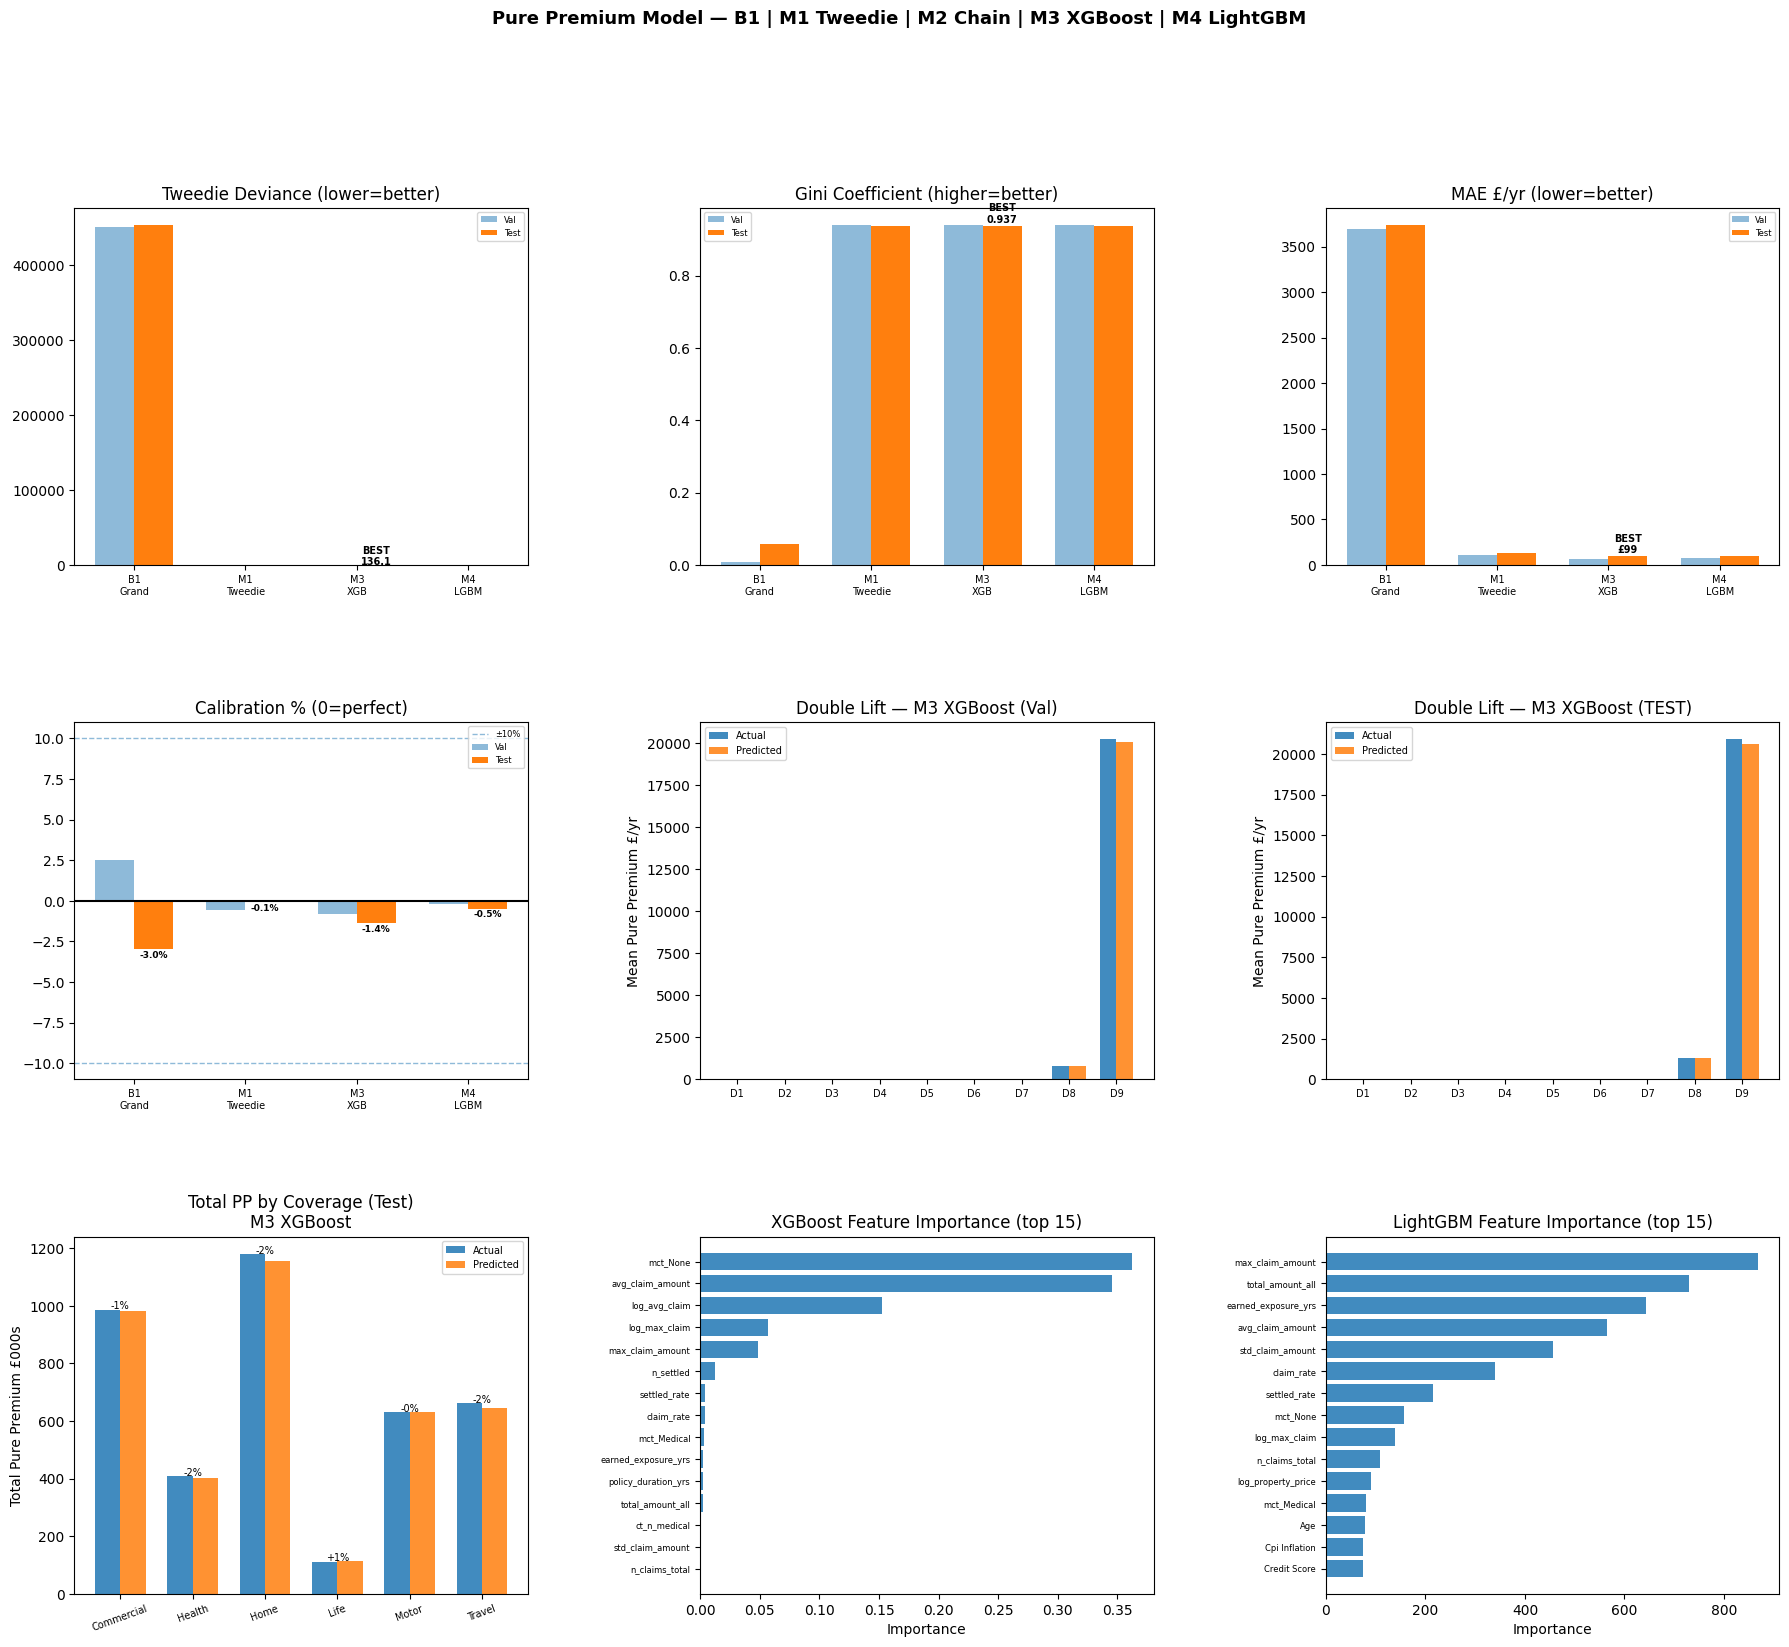

  Saved → ../output/pp_diagnostics.png


In [16]:
pred_map_v = dict(zip(MODEL_NAMES, [b1_pred_v, m1_pred_v, m3_pred_v, m4_pred_v]))
pred_map_t = dict(zip(MODEL_NAMES, [b1_pred_t, m1_pred_t, m3_pred_t, m4_pred_t]))
short = ['B1\nGrand', 'M1\nTweedie', 'M3\nXGB', 'M4\nLGBM']

fig = plt.figure(figsize=(22, 18))
fig.suptitle('Pure Premium Model — B1 | M1 Tweedie | M2 Chain | M3 XGBoost | M4 LightGBM',
             fontsize=13, fontweight='bold', y=0.99)
gs = fig.add_gridspec(3, 3, hspace=0.44, wspace=0.38)
x = np.arange(4); w = 0.35

# ── 1. Tweedie Deviance ───────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
val_d  = [s['tweedie_deviance'] for s in VAL_SCORES]
test_d = [s['tweedie_deviance'] for s in TEST_SCORES]
ax.bar(x-w/2, val_d,  w, alpha=0.5, label='Val')
ax.bar(x+w/2, test_d, w, alpha=1.0, label='Test')
best_t = int(np.argmin(test_d))
ax.annotate(f'BEST\n{test_d[best_t]:.1f}', xy=(best_t+w/2, test_d[best_t]),
            xytext=(best_t+w/2, test_d[best_t]+0.3),
            fontsize=7, fontweight='bold', ha='center')
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=7)
ax.set_title('Tweedie Deviance (lower=better)'); ax.legend(fontsize=6)

# ── 2. Gini ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
val_g  = [s['gini'] for s in VAL_SCORES]
test_g = [s['gini'] for s in TEST_SCORES]
ax.bar(x-w/2, val_g,  w, alpha=0.5, label='Val')
ax.bar(x+w/2, test_g, w, alpha=1.0, label='Test')
best_g = int(np.argmax(test_g))
ax.annotate(f'BEST\n{test_g[best_g]:.3f}', xy=(best_g+w/2, test_g[best_g]),
            xytext=(best_g+w/2, test_g[best_g]+0.01),
            fontsize=7,  fontweight='bold', ha='center')
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=7)
ax.set_title('Gini Coefficient (higher=better)'); ax.legend(fontsize=6)

# ── 3. MAE ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
val_m  = [s['mae'] for s in VAL_SCORES]
test_m = [s['mae'] for s in TEST_SCORES]
ax.bar(x-w/2, val_m,  w, alpha=0.5, label='Val')
ax.bar(x+w/2, test_m, w, alpha=1.0, label='Test')
best_m = int(np.argmin(test_m))
ax.annotate(f'BEST\n£{test_m[best_m]:,.0f}', xy=(best_m+w/2, test_m[best_m]),
            xytext=(best_m+w/2, test_m[best_m]+30),
            fontsize=7,  fontweight='bold', ha='center')
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=7)
ax.set_title('MAE £/yr (lower=better)'); ax.legend(fontsize=6)

# ── 4. Calibration % ─────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
val_c  = [s['calibration_%'] for s in VAL_SCORES]
test_c = [s['calibration_%'] for s in TEST_SCORES]
ax.bar(x-w/2, val_c,  w, alpha=0.5, label='Val')
ax.bar(x+w/2, test_c, w, alpha=1.0, label='Test')
ax.axhline(0,   color='black', lw=1.5)
ax.axhline(10,   lw=1, linestyle='--', alpha=0.5)
ax.axhline(-10,  lw=1, linestyle='--', alpha=0.5, label='±10%')
for i, v in enumerate(test_c):
    ax.text(i+w/2, v + (0.2 if v>=0 else -0.5),
            f'{v:+.1f}%', ha='center', fontsize=6.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(short, fontsize=7)
ax.set_title('Calibration % (0=perfect)'); ax.legend(fontsize=6)

# ── 5. Double lift — best val model ──────────────────────────
ax = fig.add_subplot(gs[1, 1])
best_val = MODEL_NAMES[np.argmin([s['tweedie_deviance'] for s in VAL_SCORES])]
lift_v = lift_table(y_vl.values, pred_map_v[best_val])
x2 = np.arange(len(lift_v))
ax.bar(x2-w/2, lift_v['actual'],    w,   label='Actual',    alpha=0.85)
ax.bar(x2+w/2, lift_v['predicted'], w, label='Predicted', alpha=0.85)
ax.set_title(f'Double Lift — {best_val} (Val)')
ax.set_xticks(x2); ax.set_xticklabels([f'D{i+1}' for i in range(len(lift_v))], fontsize=7)
ax.set_ylabel('Mean Pure Premium £/yr'); ax.legend(fontsize=7)

# ── 6. Double lift — best test model ─────────────────────────
ax = fig.add_subplot(gs[1, 2])
lift_t = lift_table(y_ts.values, pred_map_t[best_test_model])
x3 = np.arange(len(lift_t))
ax.bar(x3-w/2, lift_t['actual'],    w,  label='Actual',    alpha=0.85)
ax.bar(x3+w/2, lift_t['predicted'], w,   label='Predicted', alpha=0.85)
ax.set_title(f'Double Lift — {best_test_model} (TEST)')
ax.set_xticks(x3); ax.set_xticklabels([f'D{i+1}' for i in range(len(lift_t))], fontsize=7)
ax.set_ylabel('Mean Pure Premium £/yr'); ax.legend(fontsize=7)

# ── 7. Calibration by coverage type ──────────────────────────
ax = fig.add_subplot(gs[2, 0])
cov_list = sorted(df_test['Coverage Type'].unique())
act_cov  = [y_ts[df_test['Coverage Type'].values==c].sum() for c in cov_list]
pred_cov = [best_pred_t[(df_test['Coverage Type']==c).values].sum() for c in cov_list]
x4 = np.arange(len(cov_list))
ax.bar(x4-w/2, [a/1e3 for a in act_cov],  w, label='Actual',    alpha=0.85)
ax.bar(x4+w/2, [p/1e3 for p in pred_cov], w,   label='Predicted', alpha=0.85)
for i, (a, p) in enumerate(zip(act_cov, pred_cov)):
    cal = (p-a)/a*100 if a > 0 else 0
    ax.text(i, max(a,p)/1e3+1, f'{cal:+.0f}%', ha='center', fontsize=7)
ax.set_xticks(x4); ax.set_xticklabels(cov_list, rotation=20, fontsize=7)
ax.set_title(f'Total PP by Coverage (Test)\n{best_test_model}')
ax.set_ylabel('Total Pure Premium £000s'); ax.legend(fontsize=7)

# ── 8. XGBoost feature importance ────────────────────────────
ax = fig.add_subplot(gs[2, 1])
fi_plot = fi_xgb.sort_values().tail(15)
ax.barh(fi_plot.index.str[:30], fi_plot.values, alpha=0.85)
ax.set_title('XGBoost Feature Importance (top 15)')
ax.set_xlabel('Importance'); ax.tick_params(axis='y', labelsize=6)

# ── 9. LightGBM feature importance ───────────────────────────
ax = fig.add_subplot(gs[2, 2])
fi_lgb_plot = fi_lgb.sort_values().tail(15)
ax.barh(fi_lgb_plot.index.str[:30], fi_lgb_plot.values,  alpha=0.85)
ax.set_title('LightGBM Feature Importance (top 15)')
ax.set_xlabel('Importance'); ax.tick_params(axis='y', labelsize=6)

# fig.savefig(f'{OUT}pp_diagnostics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'  Saved → {OUT}pp_diagnostics.png')

## Step 14 — Save Test Predictions

In [ ]:
test_pred_df = df_test[['Policy Id','Customer Id','Coverage Type',
                         'Region','pure_premium']].copy()
test_pred_df['baseline']   = b1_pred_t
test_pred_df['m1_tweedie'] = m1_pred_t
test_pred_df['m3_xgboost'] = m3_pred_t
test_pred_df['m4_lgbm']    = m4_pred_t
test_pred_df.to_csv(f'{OUT}pp_test_predictions.csv', index=False)
print(f'  Saved → {OUT}pp_test_predictions.csv')
test_pred_df.head(10)


  Saved → ../output/pp_test_predictions.csv


,Policy Id,Customer Id,Coverage Type,Region,pure_premium,baseline,m1_tweedie,m2_chain,m3_xgboost,m4_lgbm
0,POL002575,CUST03148,Life,North West,0.000000,2145.568514,0.000232,1695.637451,0.000006,6.103937e-07
1,POL007497,CUST01516,Life,Midlands,0.000000,2145.568514,0.000341,3035.105273,0.000006,5.677906e-07
2,POL009211,CUST06337,Life,London,0.000000,2145.568514,0.000604,969.196886,0.000006,5.697746e-07
3,POL005457,CUST01130,Health,North East,0.000000,2145.568514,0.000164,969.196886,0.000006,4.583969e-07
4,POL000737,CUST07793,Travel,Midlands,0.000000,2145.568514,0.000421,475.294873,0.000006,5.714848e-07
5,POL011771,CUST07239,Home,Yorkshire,0.000000,2145.568514,0.000593,2536.668225,0.000006,5.710826e-07
6,POL000857,CUST03662,Home,Scotland,152187.500000,2145.568514,137632.464565,2536.668225,136699.265625,1.351018e+05
7,POL007274,CUST04435,Life,North West,0.000000,2145.568514,0.000327,2536.668225,0.000006,5.666798e-07
8,POL011500,CUST06125,Life,South West,1025.374775,2145.568514,1038.689039,475.294873,1044.896851,1.035740e+03
9,POL011606,CUST07624,Life,North West,0.000000,2145.568514,0.000166,1667.649790,0.000006,4.617239e-07
